## Initialization

In [ ]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import matplotlib.pyplot as plt
import time
import numpy as np

LOG.propagate = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [167]:
# Get ArtemisBLEController object
ble = get_ble_controller()

# Connect to the Artemis Device
ble.connect()

2026-03-21 03:54:37,709 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:42:0c:78:b8:49
2026-03-21 03:54:37,709 | INFO     |: Scanning for device with address: c0:42:0c:78:b8:49, service UUID: d427e7cc-c400-4597-b417-d564e20d6600
2026-03-21 03:54:47,758 | INFO     |: Found 1 device(s) advertising service d427e7cc-c400-4597-b417-d564e20d6600
2026-03-21 03:54:47,759 | INFO     |: Selecting device: F32F03E1-EF13-6043-59E7-D2AE8E670FC2 (name: Artemis BLE)
2026-03-21 03:54:55,395 | INFO     |: Connected to c0:42:0c:78:b8:49


In [127]:
ble.reload_config()

In [128]:
ble.stop_notify(ble.uuid["RX_STRING"])

ValueError: Characteristic notification never started

## Start Record

In [ ]:
times = []
left_motors = []
right_motors = []
error_values = []
integral_values = []
derivative_values = []
acc_x_values = []
acc_y_values = []
gyr_z_values = []
yaw_values = []
tof_1_values = []
tof_2_values = []

def log_handler(sender, data: bytearray):
    parts = ble.bytearray_to_string(data).split("|")
    if len(parts) == 12:
        t = float(parts[0][2:])
        l = float(parts[1][3:])
        r = float(parts[2][3:])
        e = float(parts[3][2:])
        i = float(parts[4][2:])
        d = float(parts[5][2:])
        ax = float(parts[6][3:])
        ay = float(parts[7][3:])
        gz = float(parts[8][3:])
        yw = float(parts[9][3:])
        t1 = float(parts[10][3:])
        t2 = float(parts[11][3:])

        times.append(t) # Convert microseconds to seconds
        left_motors.append(l)
        right_motors.append(r)
        error_values.append(e)
        integral_values.append(i)
        derivative_values.append(d)
        acc_x_values.append(ax)
        acc_y_values.append(ay)
        gyr_z_values.append(gz)
        yaw_values.append(yw)
        tof_1_values.append(t1)
        tof_2_values.append(t2)
        print (f"t: {t:.2f}, lm: {l:.2f}, rm: {r:.2f}, e: {e:.2f}, i: {i:.2f}, d: {d:.2f}, ax: {ax:.2f}, ay: {ay:.2f}, gz: {gz:.2f}, yw: {yw:.2f}, t1: {t1:.2f}, t2: {t2:.2f}")
    else:
        print(ble.bytearray_to_string(data))

In [168]:
ble.start_notify(ble.uuid["RX_STRING"], log_handler)


In [ ]:
ble.send_command(CMD.SET_DURATION, "2000")

In [159]:
times = []
left_motors = []
right_motors = []
error_values = []
integral_values = []
derivative_values = []
acc_x_values = []
acc_y_values = []
gyr_z_values = []
yaw_values = []
tof_1_values = []
tof_2_values = []

ble.send_command(CMD.START_RECORD, "")
time.sleep(5)
ble.send_command(CMD.SEND_LOG, "")

## Position Control

In [169]:
ble.send_command(CMD.SET_DURATION, "8000")
ble.send_command(CMD.SET_SETPOINT, "304")
ble.send_command(CMD.SET_MOTOR_MAX, "10")
ble.send_command(CMD.UPDATE_PID, "0.2|0|0")
ble.send_command(CMD.SET_EXTRAPOLATION, "0")

In [170]:
times = []
left_motors = []
right_motors = []
error_values = []
integral_values = []
derivative_values = []
acc_x_values = []
acc_y_values = []
gyr_z_values = []
yaw_values = []
tof_1_values = []
tof_2_values = []

ble.send_command(CMD.START_RECORD, "")
time.sleep(10)
ble.send_command(CMD.SEND_LOG, "")

t: 5.00, lm: 43.00, rm: 63.00, e: -530.00, i: -2.44, d: -114967.46, ax: 7.81, ay: -0.49, gz: -0.57, yw: 0.00, t1: 0.00, t2: 834.00
t: 8.00, lm: 43.00, rm: 63.00, e: -530.00, i: -2.44, d: -114967.46, ax: -14.16, ay: -2.93, gz: -2.47, yw: -0.01, t1: 0.00, t2: 834.00
t: 13.00, lm: 43.00, rm: 63.00, e: -530.00, i: -2.44, d: -114967.46, ax: -0.49, ay: -4.88, gz: 0.45, yw: -0.01, t1: 0.00, t2: 834.00
t: 16.00, lm: 43.00, rm: 63.00, e: -530.00, i: -2.44, d: -114967.46, ax: 457.03, ay: 7.81, gz: -0.51, yw: -0.01, t1: 0.00, t2: 834.00
t: 24.00, lm: 43.00, rm: 63.00, e: -530.00, i: -2.44, d: -114967.46, ax: 215.33, ay: -78.61, gz: -0.69, yw: -0.01, t1: 0.00, t2: 834.00
t: 28.00, lm: 43.00, rm: 63.00, e: -530.00, i: -2.44, d: -114967.46, ax: 250.00, ay: 65.43, gz: 3.55, yw: 0.02, t1: 0.00, t2: 834.00
t: 35.00, lm: 43.00, rm: 63.00, e: -530.00, i: -2.44, d: -114967.46, ax: -375.49, ay: -77.64, gz: 1.75, yw: 0.02, t1: 0.00, t2: 834.00
t: 38.00, lm: 43.00, rm: 63.00, e: -530.00, i: -2.44, d: -114967

## Graph

In [171]:
times = np.array(times)
left_motors = np.array(left_motors)
right_motors = np.array(right_motors)
error_values = np.array(error_values)
integral_values = np.array(integral_values)
derivative_values = np.array(derivative_values)
acc_x_values = np.array(acc_x_values)
acc_y_values = np.array(acc_y_values)
gyr_z_values = np.array(gyr_z_values)
yaw_values = np.array(yaw_values)
tof_1_values = np.array(tof_1_values)
tof_2_values = np.array(tof_2_values)

In [176]:
n = min(
    len(times), len(left_motors), len(right_motors),
    len(error_values), len(derivative_values),
    len(yaw_values), len(tof_1_values), len(tof_2_values)
)

times = times[:n]
left_motors = left_motors[:n]
right_motors = right_motors[:n]
error_values = error_values[:n]
derivative_values = derivative_values[:n]
acc_x_values = acc_x_values[:n]
tof_1_values = tof_1_values[:n]
tof_2_values = tof_2_values[:n]

In [177]:
vx = np.zeros_like(acc_x_values)

for i in range(1, len(times)):
    dt = times[i] - times[i - 1]
    if dt > 0:
        vx[i] = vx[i - 1] + acc_x_values[i] * dt
    else:
        vx[i] = vx[i - 1]


In [173]:
kp = 0.0
kd = 0.0
setpoint = 304.0
times = times / 1000.0
p_term = kp * error_values
d_term = kd * derivative_values

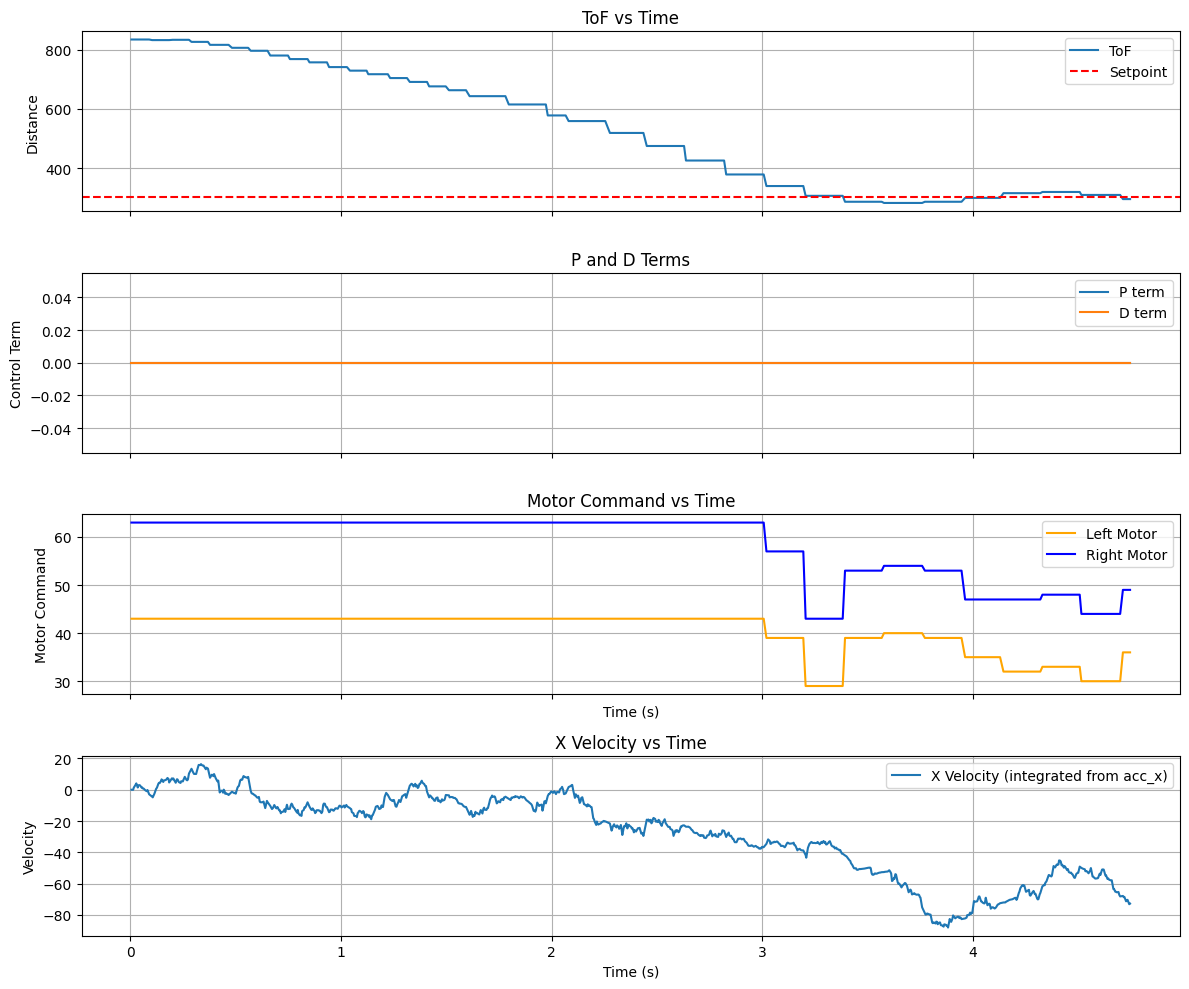

In [178]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# ToF
axes[0].plot(times, tof_2_values, label='ToF')
axes[0].axhline(setpoint, linestyle='--', label='Setpoint', color='red')
axes[0].set_ylabel('Distance')
axes[0].set_title('ToF vs Time')
axes[0].legend()
axes[0].grid(True)

# P and D
axes[1].plot(times, p_term, label='P term')
axes[1].plot(times, d_term, label='D term')
axes[1].set_ylabel('Control Term')
axes[1].set_title('P and D Terms')
axes[1].legend()
axes[1].grid(True)

# Motors
axes[2].plot(times, left_motors, label='Left Motor', color='orange')
axes[2].plot(times, right_motors, label='Right Motor', color='blue')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Motor Command')
axes[2].set_title('Motor Command vs Time')
axes[2].legend()
axes[2].grid(True)

# 4. X velocity
axes[3].plot(times, vx, label='X Velocity (integrated from acc_x)')
axes[3].set_xlabel('Time (s)')
axes[3].set_ylabel('Velocity')
axes[3].set_title('X Velocity vs Time')
axes[3].legend()
axes[3].grid(True)


plt.tight_layout()
plt.show()